# 05 — Diffusion Model per Anomaly Detection
### Emerging Jets vs QCD

In questo notebook usiamo un **diffusion model** per riconoscere jet anomali. L'idea è
insegnare al modello a *ripulire dal rumore* i jet QCD ordinari, e poi segnalare come
anomalo ogni jet che fatica a ripulire.

**Cos'è un diffusion model, intuitivamente.**
Si parte da un'osservazione semplice: se prendo un dato pulito e gli aggiungo rumore un
po' alla volta, alla fine ottengo solo rumore casuale. Un diffusion model impara a fare il
**percorso inverso** — a *togliere* il rumore, passo dopo passo. Per riuscirci deve aver
capito com'è fatto un dato "vero": è in questo senso che impara la distribuzione dei dati.

**Perché funziona per l'anomaly detection.**
Alleniamo il "ripulitore" **solo su jet QCD**. Diventa quindi bravo a ripulire jet QCD, ma
non sa nulla degli Emerging Jets. Quando gli chiediamo di ripulire un EJ, sbaglia di più:

$$\text{anomaly score} = \text{quanto male il modello ripulisce il jet} \quad (\text{più alto} = \text{più anomalo})$$

**Una premessa onesta sui risultati.** I diffusion model danno il meglio su dati ad alta
dimensione e molto strutturati (le immagini). Qui lavoriamo su una rappresentazione
compatta (43 numeri per jet): è una scelta voluta — gli stessi input di AE, VAE e NF, per
poterli **confrontare alla pari** — ma su dati così compatti è normale aspettarsi che un
flow o un autoencoder se la cavino meglio. Sfruttare a fondo la struttura "ricca" delle
tracce richiede un modello fatto apposta (un GNN), che è un task separato.

**Come procediamo.** Prepariamo i dati nello stesso formato degli altri modelli, definiamo
il processo di rumore e il denoiser, lo alleniamo sul solo QCD, costruiamo l'anomaly score
e valutiamo (distribuzione degli score, ROC, AUC, SIC), infine tuniamo gli iperparametri.


---
## 1. Setup e iperparametri

> **In breve.** Carichiamo gli strumenti e fissiamo le impostazioni. Le due manopole nuove,
> rispetto agli altri modelli, sono il **numero di passi di rumore** `T` e la **dimensione
> del denoiser** (quanti strati e quanto larghi): insieme decidono quanto è capace il modello.


In [1]:
# ── Librerie ──────────────────────────────────────────────────────────────────
import os, sys, math, warnings
warnings.filterwarnings('ignore')
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Utility del progetto (stesso preprocessing di AE/VAE/NF) ──────────────────
PROJECT_DIR = r'C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\ej_anomaly'
sys.path.insert(0, PROJECT_DIR)
from Utils_NEW import (
    load_tracks, clean_tracks, zscore_normalise,
    make_aggregate_embeddings,
    compute_roc, plot_roc,
)

# ── Path dati (locali) ────────────────────────────────────────────────────────
BKG_FILE = r'C:\Users\dfraj\Downloads\pp_output_test_background.h5'
SIG_FILE = r'C:\Users\dfraj\Downloads\pp_output_test_signal.h5'
MODELS_DIR = os.path.join(PROJECT_DIR, 'models')
PLOTS_DIR  = os.path.join(PROJECT_DIR, 'plots')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

# ── Device + riproducibilità ──────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print(f'Device: {DEVICE}')

# ── Iperparametri ─────────────────────────────────────────────────────────────
N_BKG_TRAIN   = 50_000        # jet QCD usati (riduci se la RAM non basta)
REPR          = 'aggregate'   # stesso encoding di AE/VAE/NF -> confronto alla pari

# Processo di diffusione
T             = 200          # numero di passi di rumore (livelli di rumore)
BETA_START    = 1e-4         # rumore aggiunto al primo passo
BETA_END      = 0.02         # rumore aggiunto all'ultimo passo

# Denoiser (la rete che impara a togliere il rumore)
HIDDEN_UNITS  = 256          # larghezza della rete
N_LAYERS      = 4            # numero di strati nascosti
T_EMB_DIM     = 128          # dimensione dell'embedding del tempo t

# Ottimizzazione
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-5         # regolarizzazione L2 (la "regularisation" del tuning)
BATCH_SIZE    = 512
N_EPOCHS      = 100
PATIENCE      = 15

# Anomaly score
SCORE_R       = 50           # ripetizioni per mediare lo score (più alto = più stabile)
SCORE_T_MIN   = int(0.15 * T)  # per lo score "raffinato": saltiamo i livelli di rumore più bassi

# Split 70 / 15 / 15
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
SAVE_PATH = os.path.join(MODELS_DIR, f'diffusion_locale_T{T}_h{HIDDEN_UNITS}.pt')
print(f'Setup OK -> DDPM con T={T} passi, denoiser {N_LAYERS} strati x {HIDDEN_UNITS}')


Device: cpu
Setup OK -> DDPM con T=200 passi, denoiser 4 strati x 256


---
## 2. Dati e preprocessing

> **In breve.** Trasformiamo ogni jet in un'unica «scheda» di 43 numeri che lo riassume,
> dopo aver ripulito e messo in scala i dati. È lo stesso identico input di AE, VAE e NF —
> e su questi dati è anche la scelta migliore per i modelli tabellari (la rappresentazione
> «ricca» traccia-per-traccia va sfruttata col GNN, non con un modello come questo).

I quattro passi (identici agli altri notebook):
1. **`load_tracks`** — tracce grezze (fino a 200 tracce × 14 feature) + maschera del padding.
2. **`clean_tracks`** — sostituisce NaN/Inf con la media (pulizia minima).
3. **`zscore_normalise`** — normalizza ogni feature e applica un clip di sicurezza a 10σ
   (largo: taglia solo gli artefatti numerici, non la fisica degli EJ).
4. **`make_aggregate_embeddings`** — riassume il jet in 43 numeri: media, massimo e
   deviazione standard di ciascuna delle 14 feature di traccia, più il logaritmo del numero
   di tracce.


In [2]:
print('Caricamento background (QCD)...')
tracks_bkg = load_tracks(BKG_FILE, n_max=N_BKG_TRAIN)
mask_bkg   = tracks_bkg['valid'].astype(bool)

print('Caricamento segnale (Emerging Jets)...')
tracks_sig = load_tracks(SIG_FILE)
mask_sig   = tracks_sig['valid'].astype(bool)

X_bkg_clean, mask_bkg = clean_tracks(tracks_bkg, mask_bkg)
X_sig_clean, mask_sig = clean_tracks(tracks_sig, mask_sig)

X_bkg_norm = zscore_normalise(X_bkg_clean, mask_bkg)
X_sig_norm = zscore_normalise(X_sig_clean, mask_sig)

X_bkg = make_aggregate_embeddings(X_bkg_norm, mask_bkg)
X_sig = make_aggregate_embeddings(X_sig_norm, mask_sig)
INPUT_DIM = X_bkg.shape[1]
print(f'X_bkg: {X_bkg.shape}  X_sig: {X_sig.shape}  INPUT_DIM={INPUT_DIM}')


Caricamento background (QCD)...
Caricamento segnale (Emerging Jets)...
X_bkg: (50000, 43)  X_sig: (61966, 43)  INPUT_DIM=43


---
## 3. Standardizzazione e split dei dati

> **In breve.** Dividiamo i jet QCD in tre gruppi (allenamento, controllo, test) e portiamo
> i 43 numeri a media 0 e deviazione standard 1. Serve perché il processo di rumore aggiunge
> rumore gaussiano «standard»: se i dati partono già nella scala giusta, il modello impara
> meglio ed è più stabile.

Come per il flow, calcoliamo media e deviazione standard **solo sul training** e applichiamo
la stessa trasformazione a controllo, test e segnale (usare anche il test introdurrebbe
data leakage).


In [3]:
# ── Split QCD 70 / 15 / 15 ───────────────────────────────────────────────────
rng  = np.random.default_rng(SEED)
perm = rng.permutation(len(X_bkg))
n_tr = int(len(X_bkg) * TRAIN_FRAC)
n_vl = int(len(X_bkg) * VAL_FRAC)
idx_train, idx_val, idx_test = perm[:n_tr], perm[n_tr:n_tr+n_vl], perm[n_tr+n_vl:]

X_bkg_train = X_bkg[idx_train]
X_bkg_val   = X_bkg[idx_val]
X_bkg_test  = X_bkg[idx_test]

# ── Standardizzazione: media/std SOLO dal train (niente leakage) ──────────────
agg_mean = X_bkg_train.mean(axis=0, keepdims=True)
agg_std  = X_bkg_train.std(axis=0,  keepdims=True)
agg_std[agg_std < 1e-6] = 1.0

def standardise(A):
    return ((A - agg_mean) / agg_std).astype(np.float32)

X_bkg_train_n = standardise(X_bkg_train)
X_bkg_val_n   = standardise(X_bkg_val)
X_bkg_test_n  = standardise(X_bkg_test)
X_sig_n       = standardise(X_sig)

np.savez(os.path.join(MODELS_DIR, 'diffusion_locale_norm.npz'), mean=agg_mean, std=agg_std)

# Tensori (il modello si allena solo su QCD)
X_train_t = torch.from_numpy(X_bkg_train_n)
X_val_t   = torch.from_numpy(X_bkg_val_n)
train_loader = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
n_val = len(X_val_t)

print(f'TRAIN {len(X_train_t):,} | VAL {n_val:,} | TEST {len(X_bkg_test_n):,} | SIG {len(X_sig_n):,}')
print(f'Dopo standardizzazione -> train mean~{X_bkg_train_n.mean():+.2e}, std~{X_bkg_train_n.std():.3f}')


TRAIN 35,000 | VAL 7,500 | TEST 7,500 | SIG 61,966
Dopo standardizzazione -> train mean~-1.90e-05, std~1.000


---
## 4. Il processo in avanti: aggiungere rumore

> **In breve.** Definiamo la regola con cui «sporchiamo» un jet con rumore gaussiano, in `T`
> livelli crescenti. Al livello 0 il jet è quasi intatto; all'ultimo livello è quasi solo
> rumore. Questa regola ci serve sia per allenare il denoiser sia per calcolare lo score.

La cosa comoda dei diffusion model è che non serve aggiungere il rumore un passo alla volta:
esiste una formula diretta per ottenere il jet «sporcato» al livello `t` in un colpo solo,

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon, \qquad \varepsilon \sim N(0, I)$$

dove $\bar\alpha_t$ è una quantità che parte da ~1 (poco rumore) e scende verso ~0 (tutto
rumore) man mano che `t` cresce. In pratica $\sqrt{\bar\alpha_t}$ è «quanto jet originale
resta» e $\sqrt{1-\bar\alpha_t}$ è «quanto rumore aggiungiamo». Il grafico sotto mostra
proprio queste due curve lungo i livelli.


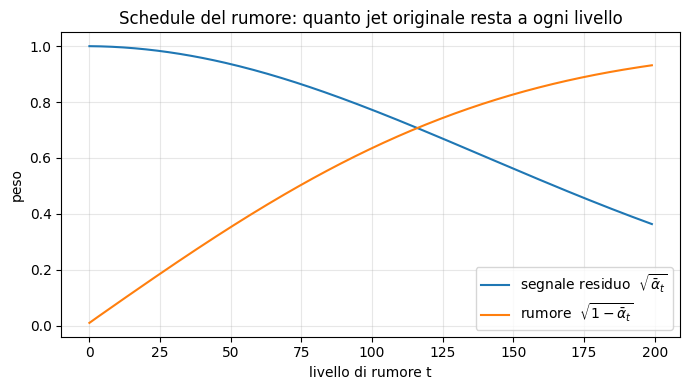

In [4]:
# ── Schedule del rumore (lineare) ────────────────────────────────────────────
betas = torch.linspace(BETA_START, BETA_END, T, device=DEVICE)
abar  = torch.cumprod(1.0 - betas, dim=0)        # alpha-bar: segnale residuo cumulato

def q_sample(x0, t, eps):
    '''Sporca i dati x0 al livello di rumore t (formula diretta).'''
    a = abar[t].sqrt()[:, None]
    b = (1.0 - abar[t]).sqrt()[:, None]
    return a * x0 + b * eps

# Visualizziamo quanto segnale resta e quanto rumore c'e' a ogni livello
ab = abar.cpu().numpy()
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.sqrt(ab),       label=r'segnale residuo  $\sqrt{\bar\alpha_t}$')
ax.plot(np.sqrt(1 - ab),   label=r'rumore  $\sqrt{1-\bar\alpha_t}$')
ax.set_xlabel('livello di rumore t'); ax.set_ylabel('peso')
ax.set_title('Schedule del rumore: quanto jet originale resta a ogni livello')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'diffusion_schedule.png'), dpi=130, bbox_inches='tight')
plt.show()


---
## 5. Il denoiser: la rete che toglie il rumore

> **In breve.** Costruiamo la rete che fa il lavoro vero: riceve un jet sporcato e il livello
> di rumore `t`, e cerca di **indovinare il rumore** che è stato aggiunto. Se sa indovinare il
> rumore, sa anche ripulire il jet.

Due dettagli:
- la rete deve sapere **a quale livello `t`** sta lavorando (togliere poco rumore o tanto è
  diverso). Le diamo questa informazione con un *time embedding*: trasformiamo il numero `t`
  in un vettore di seni e coseni a frequenze diverse — un modo standard per dare un «orologio»
  alla rete;
- il resto è un semplice **MLP** che prende il jet sporcato + l'embedding del tempo e produce
  in uscita il rumore stimato (stessa dimensione del jet, 43 numeri).


In [5]:
def timestep_embedding(t, dim):
    '''Trasforma il numero del livello t in un vettore di seni/coseni (un "orologio").'''
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / half)
    args = t[:, None].float() * freqs[None]
    return torch.cat([torch.cos(args), torch.sin(args)], dim=1)

class Denoiser(nn.Module):
    '''MLP che, dato (jet sporcato, livello t), predice il rumore aggiunto.'''
    def __init__(self, dim, hidden=256, n_layers=4, t_dim=128):
        super().__init__()
        self.t_dim = t_dim
        # piccola rete che elabora l'embedding del tempo
        self.t_mlp = nn.Sequential(nn.Linear(t_dim, hidden), nn.SiLU(), nn.Linear(hidden, hidden))
        # rete principale: prende [jet sporcato | tempo] e predice il rumore
        layers = [nn.Linear(dim + hidden, hidden), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        te = self.t_mlp(timestep_embedding(t, self.t_dim))
        return self.net(torch.cat([x, te], dim=1))


def build_denoiser(dim, hidden, n_layers):
    return Denoiser(dim, hidden=hidden, n_layers=n_layers, t_dim=T_EMB_DIM)

model = build_denoiser(INPUT_DIM, HIDDEN_UNITS, N_LAYERS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'Denoiser: {N_LAYERS} strati x {HIDDEN_UNITS}  ->  {n_params:,} parametri')


Denoiser: 4 strati x 256  ->  384,043 parametri


---
## 6. Addestramento (solo su QCD)

> **In breve.** Alleniamo il denoiser con un gioco semplice ripetuto tante volte: prendi un
> jet QCD, sporcalo a un livello di rumore `t` a caso, e chiedi alla rete di indovinare il
> rumore aggiunto. L'errore (quanto sbaglia) è la cosa che minimizziamo.

Selezioniamo il modello sulla **stessa misura, ma calcolata sui jet di controllo (validation)**:
è quanto bene il denoiser ripulisce jet QCD che non ha usato per allenarsi. Per avere una curva
di validation pulita e confrontabile tra le epoche, fissiamo una volta sola i livelli di rumore
e il rumore usati in validation. Il segnale non entra mai.


In [6]:
opt   = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=max(1, PATIENCE // 3), factor=0.5)

# Rumore di validation FISSO (così la val-loss e' confrontabile epoca per epoca)
g = torch.Generator(device='cpu').manual_seed(SEED)
val_t   = torch.randint(0, T, (n_val,), generator=g)
val_eps = torch.randn(n_val, INPUT_DIM, generator=g)

best_val, wait = float('inf'), 0
train_losses, val_losses = [], []
print(f'{"Epoca":>6} {"Train loss":>12} {"Val loss":>12} {"LR":>10}')
print('-' * 44)

for epoch in range(1, N_EPOCHS + 1):
    # ── Training ─────────────────────────────────────────────────────────────
    model.train(); tr = 0.0
    for (xb,) in train_loader:
        xb  = xb.to(DEVICE)
        t   = torch.randint(0, T, (xb.size(0),), device=DEVICE)   # livello di rumore casuale
        eps = torch.randn_like(xb)                                # rumore vero
        xt  = q_sample(xb, t, eps)                                # jet sporcato
        eps_hat = model(xt, t)                                    # rumore stimato
        loss = ((eps_hat - eps) ** 2).mean()                      # errore di denoising
        opt.zero_grad(); loss.backward(); opt.step()
        tr += loss.item() * len(xb)
    train_loss = tr / len(train_loader.dataset)

    # ── Validation (rumore fisso, solo QCD) ──────────────────────────────────
    model.eval()
    with torch.no_grad():
        xv   = X_val_t.to(DEVICE); tv = val_t.to(DEVICE); ev = val_eps.to(DEVICE)
        xtv  = q_sample(xv, tv, ev)
        val_loss = ((model(xtv, tv) - ev) ** 2).mean().item()

    sched.step(val_loss)
    train_losses.append(train_loss); val_losses.append(val_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6} {train_loss:>12.4f} {val_loss:>12.4f} {opt.param_groups[0]["lr"]:>10.2e}')

    # ── Early stopping sul val ───────────────────────────────────────────────
    if val_loss < best_val - 1e-4:
        best_val, wait = val_loss, 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f'Early stopping a epoca {epoch}'); break

model.load_state_dict(torch.load(SAVE_PATH, weights_only=True))
print(f'\nBest val loss = {best_val:.4f}  | modello salvato in {SAVE_PATH}')


 Epoca   Train loss     Val loss         LR
--------------------------------------------
     1       0.8360       0.6730   1.00e-03
     5       0.5017       0.4972   1.00e-03
    10       0.4709       0.4651   1.00e-03
    15       0.4544       0.4525   1.00e-03
    20       0.4502       0.4443   1.00e-03
    25       0.4433       0.4393   1.00e-03
    30       0.4366       0.4355   1.00e-03
    35       0.4392       0.4324   1.00e-03
    40       0.4350       0.4299   1.00e-03
    45       0.4326       0.4298   1.00e-03
    50       0.4293       0.4273   1.00e-03
    55       0.4286       0.4252   1.00e-03
    60       0.4253       0.4253   1.00e-03
    65       0.4244       0.4231   1.00e-03
    70       0.4243       0.4214   1.00e-03
    75       0.4234       0.4209   1.00e-03
    80       0.4204       0.4187   1.00e-03
    85       0.4202       0.4170   1.00e-03
    90       0.4217       0.4150   1.00e-03
    95       0.4166       0.4132   1.00e-03
   100       0.4144       0.411

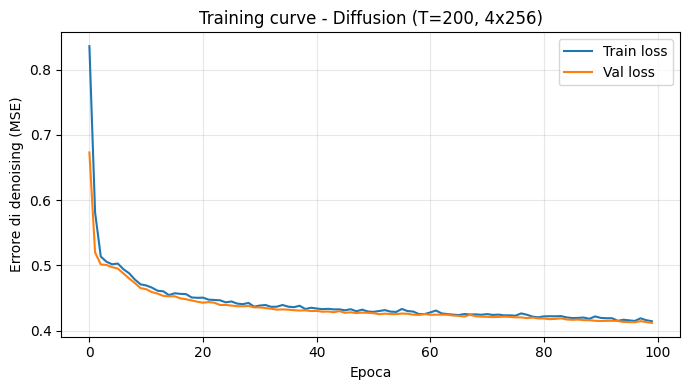

In [7]:
# ── Curva di training: errore di denoising su train e validation ────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, label='Train loss')
ax.plot(val_losses,   label='Val loss')
ax.set_xlabel('Epoca'); ax.set_ylabel('Errore di denoising (MSE)')
ax.set_title(f'Training curve - Diffusion (T={T}, {N_LAYERS}x{HIDDEN_UNITS})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'diffusion_training_curve.png'), dpi=130, bbox_inches='tight')
plt.show()


---
## 7. Anomaly score: quanto male il modello ripulisce un jet

> **In breve.** Per ogni jet misuriamo quanto il denoiser, allenato solo su QCD, sbaglia a
> indovinare il rumore. Ripetiamo la prova su molti livelli di rumore e mediamo: i jet QCD si
> ripuliscono bene (errore piccolo), gli Emerging Jets no (errore grande → score alto).

**Un punto metodologico importante (lo score «onesto»).** Quale errore usare conta. Abbiamo
due versioni:
- **media su tutti i livelli di rumore** — la versione più conservativa: non facciamo
  *nessuna* scelta guardando il segnale, quindi è inattaccabile;
- **saltando i livelli di rumore più bassi** — un raffinamento *giustificato dal solo QCD*: a
  rumore bassissimo il denoising è banale per qualunque jet (l'errore è minuscolo per tutti,
  lo si vede già sul QCD), quindi quei livelli non portano informazione utile. La soglia la
  fissiamo a priori (i livelli sotto il 15%), **non** scegliendola per far salire l'AUC —
  farlo significherebbe usare il segnale, cioè barare.

Riportiamo entrambi per trasparenza e usiamo il secondo (più informativo ma comunque onesto)
come score principale.


In [8]:
def diffusion_score(model, X_np, t_min=0, R=SCORE_R, batch=8192):
    '''Anomaly score = errore medio di denoising su R prove, con livelli di rumore in [t_min, T).'''
    model.eval()
    Xt = torch.from_numpy(X_np.astype(np.float32))
    out = torch.zeros(len(Xt))
    with torch.no_grad():
        for st in range(0, len(Xt), batch):
            xb = Xt[st:st+batch].to(DEVICE)
            s  = torch.zeros(len(xb), device=DEVICE)
            for _ in range(R):
                t   = torch.randint(t_min, T, (len(xb),), device=DEVICE)
                eps = torch.randn_like(xb)
                s  += ((model(q_sample(xb, t, eps), t) - eps) ** 2).mean(1)
            out[st:st+batch] = (s / R).cpu()
    return out.numpy()

# PRIMA volta che test-QCD e segnale vengono toccati - nessun leakage.
# Score principale (onesto, raffinato): salta i livelli di rumore piu' bassi.
scores_bkg = diffusion_score(model, X_bkg_test_n, t_min=SCORE_T_MIN)
scores_sig = diffusion_score(model, X_sig_n,      t_min=SCORE_T_MIN)
# Score di riferimento (onesto, conservativo): tutti i livelli.
scores_bkg_all = diffusion_score(model, X_bkg_test_n, t_min=0)
scores_sig_all = diffusion_score(model, X_sig_n,      t_min=0)

print(f'[score principale, salta i piu bassi]')
print(f'  QCD (test): {scores_bkg.mean():.4f} +/- {scores_bkg.std():.4f}')
print(f'  EJ        : {scores_sig.mean():.4f} +/- {scores_sig.std():.4f}')
print(f'  Delta (EJ - QCD): {scores_sig.mean() - scores_bkg.mean():+.4f}  (positivo = EJ piu anomalo)')


[score principale, salta i piu bassi]
  QCD (test): 0.3423 +/- 0.0525
  EJ        : 0.4272 +/- 0.0948
  Delta (EJ - QCD): +0.0848  (positivo = EJ piu anomalo)


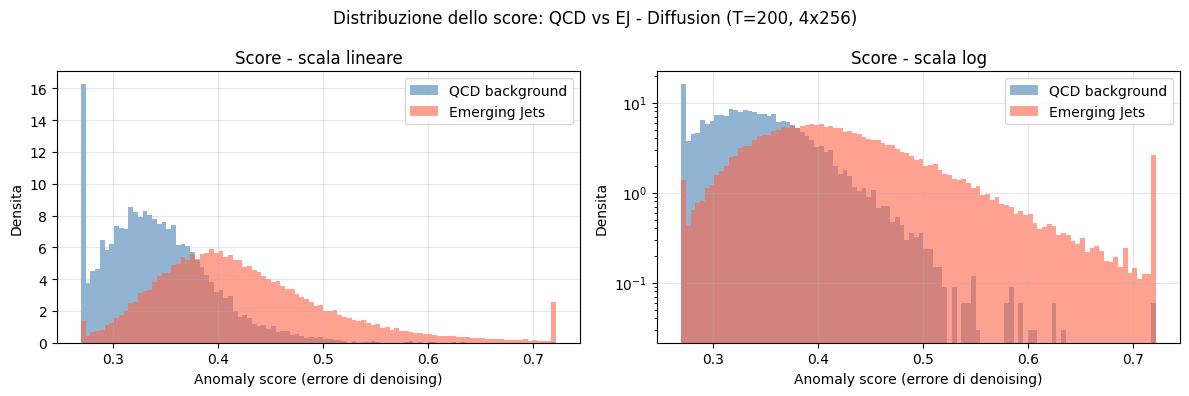

In [9]:
# ── Istogramma dello score: jet normali (QCD) vs anomali (EJ) ────────────────
both = np.concatenate([scores_bkg, scores_sig])
lo, hi = np.percentile(both, 1), np.percentile(both, 99)
sb, ss = np.clip(scores_bkg, lo, hi), np.clip(scores_sig, lo, hi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, logy in zip(axes, [False, True]):
    ax.hist(sb, bins=100, density=True, alpha=0.6, label='QCD background', color='steelblue')
    ax.hist(ss, bins=100, density=True, alpha=0.6, label='Emerging Jets',  color='tomato')
    ax.set_xlabel('Anomaly score (errore di denoising)'); ax.set_ylabel('Densita')
    ax.set_title('Score - scala log' if logy else 'Score - scala lineare')
    if logy: ax.set_yscale('log')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle(f'Distribuzione dello score: QCD vs EJ - Diffusion (T={T}, {N_LAYERS}x{HIDDEN_UNITS})')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'diffusion_score_distributions.png'), dpi=130, bbox_inches='tight')
plt.show()


---
## 8. Valutazione — ROC, AUC e SIC

> **In breve.** Misuriamo quanto bene lo score separa il segnale dal fondo con le metriche
> standard (ROC, AUC, SIC), le stesse di AE/VAE/NF così il confronto è diretto. Mostriamo sia
> lo score principale sia quello conservativo (tutti i livelli), per trasparenza.


  **Perché vedrai due AUC.** È lo *stesso* modello e lo *stesso* score (l'errore di denoising):
  le due AUC differiscono solo per *su quali livelli di rumore* mediamo l'errore.
  - **principale** — salta i livelli di rumore più bassi, dove ripulire è banale per qualunque
    jet e quindi non distingue nulla. È lo score più nitido: **è il numero da tenere come risultato.**
  - **riferimento** — media su *tutti* i livelli. Più conservativo, lo riportiamo solo per
    trasparenza: mostra che il raffinamento aiuta (~+0.02) e non nasconde nulla.

  In sintesi: **riporta l'AUC «principale»**; l'altra è il baseline onesto di controllo.

VALUTAZIONE FINALE (test-QCD + segnale, mai visti in addestramento)
  Config : T=200, denoiser 4x256, wd=1e-05
  AUC (score principale, salta i piu bassi) : 0.8098
  AUC (riferimento, tutti i livelli)        : 0.7891
  N test-QCD: 7,500  |  N segnale: 61,966


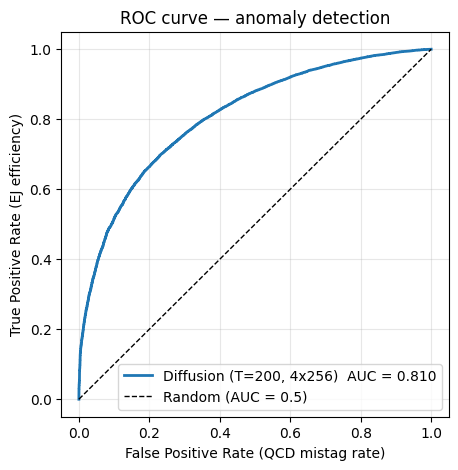

SIC massima : 2.095 @ eps_S = 0.13


In [10]:
# Score principale (raffinato, onesto)
fpr, tpr, roc_auc = compute_roc(scores_bkg, scores_sig)
# Score conservativo (tutti i livelli) - solo come riferimento
_, _, auc_all = compute_roc(scores_bkg_all, scores_sig_all)

# Due AUC dallo STESSO modello e STESSO score (errore di denoising): cambiano solo
# i livelli di rumore su cui mediamo.
#  - principale (salta i piu bassi): livelli bassi = ripulire banale per tutti -> non
#    distinguono nulla; saltandoli lo score e' piu nitido. >>> e' il numero da riportare.
#  - riferimento (tutti i livelli): piu conservativo, solo per trasparenza (mostra che
#    il raffinamento aiuta ~+0.02 e non nasconde nulla).

print('=' * 55)
print('VALUTAZIONE FINALE (test-QCD + segnale, mai visti in addestramento)')
print('=' * 55)
print(f'  Config : T={T}, denoiser {N_LAYERS}x{HIDDEN_UNITS}, wd={WEIGHT_DECAY}')
print(f'  AUC (score principale, salta i piu bassi) : {roc_auc:.4f}')
print(f'  AUC (riferimento, tutti i livelli)        : {auc_all:.4f}')
print(f'  N test-QCD: {len(scores_bkg):,}  |  N segnale: {len(scores_sig):,}')

plot_roc(fpr, tpr, roc_auc,
         label=f'Diffusion (T={T}, {N_LAYERS}x{HIDDEN_UNITS})',
         save_path=os.path.join(PLOTS_DIR, 'diffusion_roc_finale.png'))
plt.show()

m   = fpr > 0
sic = tpr[m] / np.sqrt(fpr[m])
print(f'SIC massima : {sic.max():.3f} @ eps_S = {tpr[m][sic.argmax()]:.2f}')


---
## 9. Tuning degli iperparametri

> **In breve.** Cerchiamo le impostazioni migliori provando diverse «taglie» del denoiser
> (più o meno strati e neuroni) e diversi livelli di regolarizzazione. Il criterio è sempre
> l'errore di denoising sui jet di **controllo** (QCD), mai il segnale.

Le manopole, tradotte per un diffusion model:
- **Profondità** (`n_layers`) e **larghezza** (`hidden`): la *capacità* del denoiser. Più
  capacità → errore di validation più basso, in modo monotòno → si sceglie il **gomito**
  (Occam), non il minimo, per non rendere il modello inutilmente pesante.
- **Regolarizzazione** (`weight_decay`): non è capacità → si sceglie il valore con l'errore
  di validation **minimo**.
- **Input encoding**: già fissato ad `aggregate`. Su questi dati è anche la scelta migliore
  per i modelli tabellari (su questi dati una versione track-level del flow rende molto meno);
  la rappresentazione «ricca» traccia-per-traccia va sfruttata con un modello set/grafo-aware,
  cioè il GNN — non con un MLP/diffusion tabellare.

Il criterio di selezione è la **val-loss di denoising sul QCD**, mai l'AUC (che richiede il
segnale e va guardata solo a posteriori).


In [11]:
def train_diffusion_for_tuning(n_layers, hidden, weight_decay,
                               n_epochs=30, lr=1e-3, patience=7, device=DEVICE):
    '''Allena un denoiser (solo QCD) e restituisce la miglior val-loss di denoising.
       30 epoche bastano per confrontare RELATIVAMENTE le configurazioni; niente segnale.'''
    torch.manual_seed(SEED)
    m   = build_denoiser(INPUT_DIM, hidden, n_layers).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    g = torch.Generator(device='cpu').manual_seed(SEED)
    vt = torch.randint(0, T, (n_val,), generator=g); ve = torch.randn(n_val, INPUT_DIM, generator=g)
    best, wait = float('inf'), 0
    for _ in range(n_epochs):
        m.train()
        for (xb,) in train_loader:
            xb = xb.to(device)
            t = torch.randint(0, T, (xb.size(0),), device=device); eps = torch.randn_like(xb)
            loss = ((m(q_sample(xb, t, eps), t) - eps) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            xv = X_val_t.to(device); tv = vt.to(device); ev = ve.to(device)
            val = ((m(q_sample(xv, tv, ev), tv) - ev) ** 2).mean().item()
        sched.step(val)
        if val < best - 1e-4:
            best, wait = val, 0
        else:
            wait += 1
            if wait >= patience: break
    return best


In [12]:
# ━━━ Esperimento 1 - Profondità del denoiser (n_layers) ━━━━━━━━━━━━━━━━━━━━━━
# Capacita' monotona -> scegli il GOMITO, non il minimo.
print('Esperimento 1: profondita  (criterio: val-loss denoising QCD)')
print(f"{'n_layers':>9} | {'val loss':>12}")
print('-' * 26)
depth_results = {}
for L in [2, 4, 6, 8]:
    depth_results[L] = train_diffusion_for_tuning(L, HIDDEN_UNITS, WEIGHT_DECAY)
    print(f'{L:>9} | {depth_results[L]:>12.5f}')


Esperimento 1: profondita  (criterio: val-loss denoising QCD)
 n_layers |     val loss
--------------------------
        2 |      0.43433
        4 |      0.43554
        6 |      0.47256
        8 |      1.00059


In [13]:
# ━━━ Esperimento 2 - Larghezza del denoiser (hidden) ━━━━━━━━━━━━━━━━━━━━━━━━━
# Anche la larghezza e' capacita': di nuovo si guarda il GOMITO.
print('Esperimento 2: larghezza  (criterio: val-loss denoising QCD)')
print(f"{'hidden':>9} | {'val loss':>12}")
print('-' * 26)
width_results = {}
for H in [128, 256, 384, 512]:
    width_results[H] = train_diffusion_for_tuning(N_LAYERS, H, WEIGHT_DECAY)
    print(f'{H:>9} | {width_results[H]:>12.5f}')


Esperimento 2: larghezza  (criterio: val-loss denoising QCD)
   hidden |     val loss
--------------------------
      128 |      0.45515
      256 |      0.43554
      384 |      0.42669
      512 |      0.42298


In [14]:
# ━━━ Esperimento 3 - Regolarizzazione (weight_decay) ━━━━━━━━━━━━━━━━━━━━━━━━━
# La regolarizzazione non e' capacita': qui il criterio e' la val-loss MINIMA.
print('Esperimento 3: weight_decay  (criterio: val-loss denoising QCD minima)')
print(f"{'weight_decay':>13} | {'val loss':>12}")
print('-' * 30)
wd_results = {}
for wd in [0.0, 1e-5, 1e-4, 1e-3]:
    wd_results[wd] = train_diffusion_for_tuning(N_LAYERS, HIDDEN_UNITS, wd)
    print(f'{wd:>13.0e} | {wd_results[wd]:>12.5f}')
best_wd = min(wd_results, key=wd_results.get)
print(f'\nMiglior weight_decay (val-loss minima): {best_wd:.0e}')


Esperimento 3: weight_decay  (criterio: val-loss denoising QCD minima)
 weight_decay |     val loss
------------------------------
        0e+00 |      0.43557
        1e-05 |      0.43554
        1e-04 |      0.43676
        1e-03 |      1.00059

Miglior weight_decay (val-loss minima): 1e-05


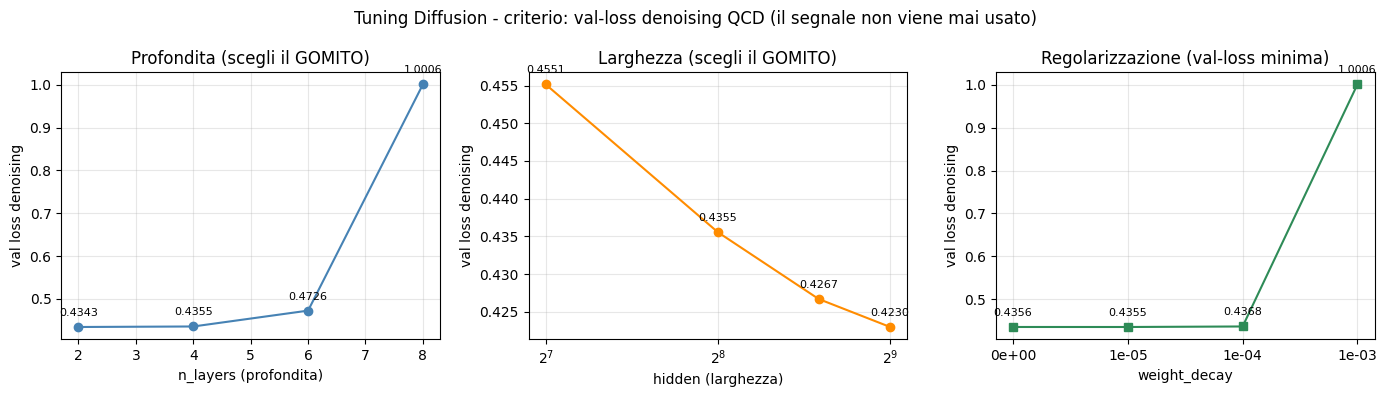

In [15]:
# ── Riepilogo del tuning: una curva per ciascuna manopola ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ks, vs = list(depth_results), list(depth_results.values())
ax.plot(ks, vs, 'o-', color='steelblue')
ax.set_xlabel('n_layers (profondita)'); ax.set_ylabel('val loss denoising')
ax.set_title('Profondita (scegli il GOMITO)'); ax.grid(alpha=0.3)
for k, v in zip(ks, vs):
    ax.annotate(f'{v:.4f}', (k, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

ax = axes[1]
ks, vs = list(width_results), list(width_results.values())
ax.plot(ks, vs, 'o-', color='darkorange'); ax.set_xscale('log', base=2)
ax.set_xlabel('hidden (larghezza)'); ax.set_ylabel('val loss denoising')
ax.set_title('Larghezza (scegli il GOMITO)'); ax.grid(alpha=0.3)
for k, v in zip(ks, vs):
    ax.annotate(f'{v:.4f}', (k, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

ax = axes[2]
labels = [f'{w:.0e}' for w in wd_results]; vs = list(wd_results.values()); xs = list(range(len(labels)))
ax.plot(xs, vs, 's-', color='seagreen')
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_xlabel('weight_decay'); ax.set_ylabel('val loss denoising')
ax.set_title('Regolarizzazione (val-loss minima)'); ax.grid(alpha=0.3)
for x, v in zip(xs, vs):
    ax.annotate(f'{v:.4f}', (x, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

plt.suptitle('Tuning Diffusion - criterio: val-loss denoising QCD (il segnale non viene mai usato)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'diffusion_tuning_summary.png'), dpi=130, bbox_inches='tight')
plt.show()


## Scelta di design: anomaly-score *whitened*

Lo score della diffusion e' l'errore medio di denoising, mediato sulle 43 dimensioni con **peso uguale**. Lo rendiamo **whitened**: dividiamo l'errore di ogni dimensione per la sua varianza di denoising sul QCD (stimata sul val). Stesso modello, solo lo score cambia. Confrontiamo e adottiamo il migliore.

In [12]:
# === DESIGN CHOICE (whitened) ===
import numpy as np, torch
def _diff_perdim(Xnp, R=SCORE_R, t_min=SCORE_T_MIN, bs=8192):
    model.eval(); Xt = torch.from_numpy(Xnp.astype(np.float32)); out = torch.zeros(len(Xt), Xt.shape[1])
    with torch.no_grad():
        for st in range(0, len(Xt), bs):
            xb = Xt[st:st+bs].to(DEVICE); acc = torch.zeros(len(xb), xb.shape[1], device=DEVICE)
            for _ in range(R):
                t = torch.randint(t_min, T, (len(xb),), device=DEVICE); eps = torch.randn_like(xb)
                acc += (model(q_sample(xb, t, eps), t) - eps)**2
            out[st:st+bs] = (acc/R).cpu()
    return out.numpy()
_var = _diff_perdim(X_bkg_val_n).mean(0) + 1e-6
_ete, _esg = _diff_perdim(X_bkg_test_n), _diff_perdim(X_sig_n)
scores_bkg_base, scores_sig_base = _ete.mean(1), _esg.mean(1)
scores_bkg_official = (_ete/_var).mean(1); scores_sig_official = (_esg/_var).mean(1)
_ab = compute_roc(scores_bkg_base, scores_sig_base)[2]
_aw = compute_roc(scores_bkg_official, scores_sig_official)[2]
print(f'AUC baseline (denoise medio): {_ab:.4f}  |  whitened: {_aw:.4f}  |  delta {_aw-_ab:+.4f}')

AUC baseline (denoise medio): 0.8097  |  whitened: 0.8408  |  delta +0.0311


## Export per la Task 3 - salvataggio degli anomaly-score

Salva lo score **ufficiale** del modello (lo *whitened* dove adottato, altrimenti il baseline) e, per sicurezza, anche il **baseline** (`scores_*_base`), piu' gli indici `idx_sig`/`idx_bkg` per agganciare decay length e massa. Ricaricati dal notebook `08` per il confronto, senza riallenare.

In [13]:
# === TASK3 EXPORT ===
# Salva gli anomaly-score (ufficiale + baseline) per il confronto in 08_evaluation_task3_locale.
import os, numpy as np
TASK3_DIR = "C:/Users/dfraj/OneDrive/Desktop/Master/Adv_ML/Progetto/ej_anomaly/notebooks_locali/task3_scores"
os.makedirs(TASK3_DIR, exist_ok=True)
# score ufficiale del modello (whitened se definito, altrimenti baseline del notebook)
sb = (scores_bkg_official if 'scores_bkg_official' in dir() else
      scores_bkg_test if 'scores_bkg_test' in dir() else scores_bkg)
ss = (scores_sig_official if 'scores_sig_official' in dir() else
      scores_sig_final if 'scores_sig_final' in dir() else scores_sig)
sb = np.asarray(sb, np.float32); ss = np.asarray(ss, np.float32)
idx_sig = np.arange(len(ss), dtype=np.int32)
_it = idx_test if 'idx_test' in dir() else (ite if 'ite' in dir() else None)
idx_bkg = np.asarray(_it, np.int32) if _it is not None else np.arange(len(sb), np.int32)
assert len(idx_bkg) == len(sb)
extra = {}
if 'scores_bkg_base' in dir() and 'scores_sig_base' in dir():
    extra['scores_bkg_base'] = np.asarray(scores_bkg_base, np.float32)
    extra['scores_sig_base'] = np.asarray(scores_sig_base, np.float32)
_path = os.path.join(TASK3_DIR, "diffusion.npz")
np.savez_compressed(_path, scores_bkg=sb, scores_sig=ss, idx_sig=idx_sig, idx_bkg=idx_bkg,
                    model_name="Diffusion", **extra)
print(f"[Task 3] Salvato {_path} | bkg {len(sb):,} | sig {len(ss):,}" + (" (+baseline)" if extra else ""))
try:
    from sklearn.metrics import roc_auc_score
    y = np.r_[np.zeros(len(sb)), np.ones(len(ss))]
    print(f"         AUC ufficiale: {roc_auc_score(y, np.r_[sb, ss]):.4f}")
except Exception as e:
    print("         (AUC quick-check non disponibile)", e)

[Task 3] Salvato C:/Users/dfraj/OneDrive/Desktop/Master/Adv_ML/Progetto/ej_anomaly/notebooks_locali/task3_scores\diffusion.npz | bkg 7,500 | sig 61,966 (+baseline)
         AUC ufficiale: 0.8408
